In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)
df["occupancy_rate"] = 1 - (df["availability_365"] / 365)

# Filter: remove extreme outliers
df = df[df["price"].between(100, 10000)].copy()
print(f"Modeling dataset: {df.shape}")
print(f"Price range: ฿{df['price'].min():,.0f} — ฿{df['price'].max():,.0f}")
print(f"Median price: ฿{df['price'].median():,.0f}")

Modeling dataset: (22801, 96)
Price range: ฿122 — ฿10,000
Median price: ฿1,359


In [7]:
# --- Feature Engineering ---

# 1. Room type encoding
df["room_type_encoded"] = df["room_type"].map({
    "Entire Home/Apt": 3,
    "Hotel Room": 2,
    "Private Room": 1,
    "Shared Room": 0
})

# 2. Neighbourhood median price (already in enriched)
# 3. Boolean to int
bool_cols = ["host_is_superhost", "host_identity_verified", "instant_bookable"]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).map({"True": 1, "False": 0, "1.0": 1, "0.0": 0})

# 4. Amenity count
if "amenities" in df.columns:
    df["amenity_count"] = df["amenities"].astype(str).apply(
        lambda x: len(x.split(",")) if x != "nan" else 0
    )

# 5. Select features
features = [
    "accommodates", "bedrooms", "beds",
    "minimum_nights", "availability_365",
    "number_of_reviews", "review_scores_rating",
    "review_scores_cleanliness", "review_scores_location",
    "host_tenure_years", "host_listing_count_actual",
    "host_is_superhost", "host_identity_verified",
    "instant_bookable", "room_type_encoded",
    "neighbourhood_median_price", "neighbourhood_listing_count",
    "occupancy_rate", "amenity_count"
]

existing_features = [f for f in features if f in df.columns]
print(f"Features used: {len(existing_features)}")
print(existing_features)

# 6. Prepare X, y
model_df = df[existing_features + ["price"]].dropna()
X = model_df[existing_features]
y = np.log1p(model_df["price"])  # log transform

print(f"\nTraining samples: {len(X)}")
print(f"Target (log price) — mean: {y.mean():.3f}, std: {y.std():.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Features used: 19
['accommodates', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'host_tenure_years', 'host_listing_count_actual', 'host_is_superhost', 'host_identity_verified', 'instant_bookable', 'room_type_encoded', 'neighbourhood_median_price', 'neighbourhood_listing_count', 'occupancy_rate', 'amenity_count']

Training samples: 14708
Target (log price) — mean: 7.243, std: 0.640
Train: 11766, Test: 2942


In [8]:
# --- Train & Compare 3 Models ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate(name, model, X_tr, X_te, scaled=False):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    preds_actual = np.expm1(preds)
    y_actual = np.expm1(y_test)
    
    mae = mean_absolute_error(y_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, preds_actual))
    mape = np.mean(np.abs((y_actual - preds_actual) / y_actual)) * 100
    r2 = model.score(X_te, y_test)
    
    print(f"\n{name}")
    print(f"  MAE:  ฿{mae:,.0f}")
    print(f"  RMSE: ฿{rmse:,.0f}")
    print(f"  MAPE: {mape:.1f}%")
    print(f"  R²:   {r2:.4f}")
    return {"Model": name, "MAE": round(mae), "RMSE": round(rmse), 
            "MAPE": round(mape, 1), "R2": round(r2, 4), 
            "predictions": preds_actual, "model": model}

results = {}

# Model 1: Ridge Regression
ridge = Ridge(alpha=10)
results["Ridge"] = evaluate("Ridge Regression", ridge, 
                             X_train_scaled, X_test_scaled)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=12, 
                            random_state=42, n_jobs=-1)
results["RandomForest"] = evaluate("Random Forest", rf, 
                                    X_train, X_test)

# Model 3: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, 
                                learning_rate=0.05, random_state=42)
results["GradientBoosting"] = evaluate("Gradient Boosting", gb, 
                                        X_train, X_test)

# Summary table
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["predictions", "model"]}
    for r in results.values()
])
print("\n--- Model Comparison ---")
print(summary.to_string(index=False))


Ridge Regression
  MAE:  ฿765
  RMSE: ฿4,689
  MAPE: 42.1%
  R²:   0.4490

Random Forest
  MAE:  ฿514
  RMSE: ฿926
  MAPE: 29.2%
  R²:   0.6522

Gradient Boosting
  MAE:  ฿519
  RMSE: ฿936
  MAPE: 29.1%
  R²:   0.6622

--- Model Comparison ---
            Model  MAE  RMSE  MAPE     R2
 Ridge Regression  765  4689  42.1 0.4490
    Random Forest  514   926  29.2 0.6522
Gradient Boosting  519   936  29.1 0.6622


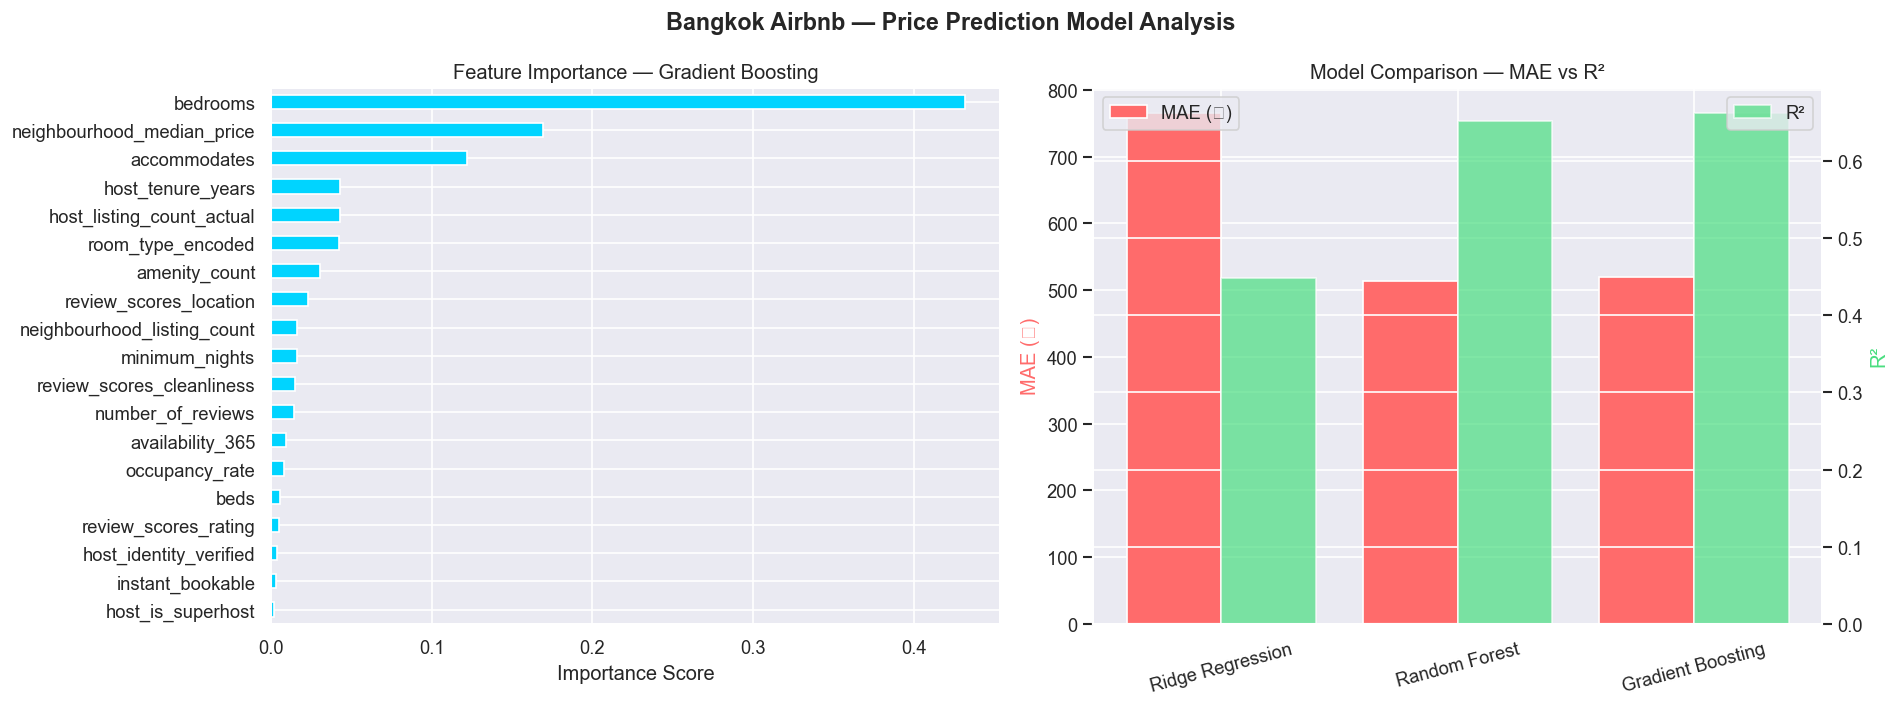

Computing SHAP values...


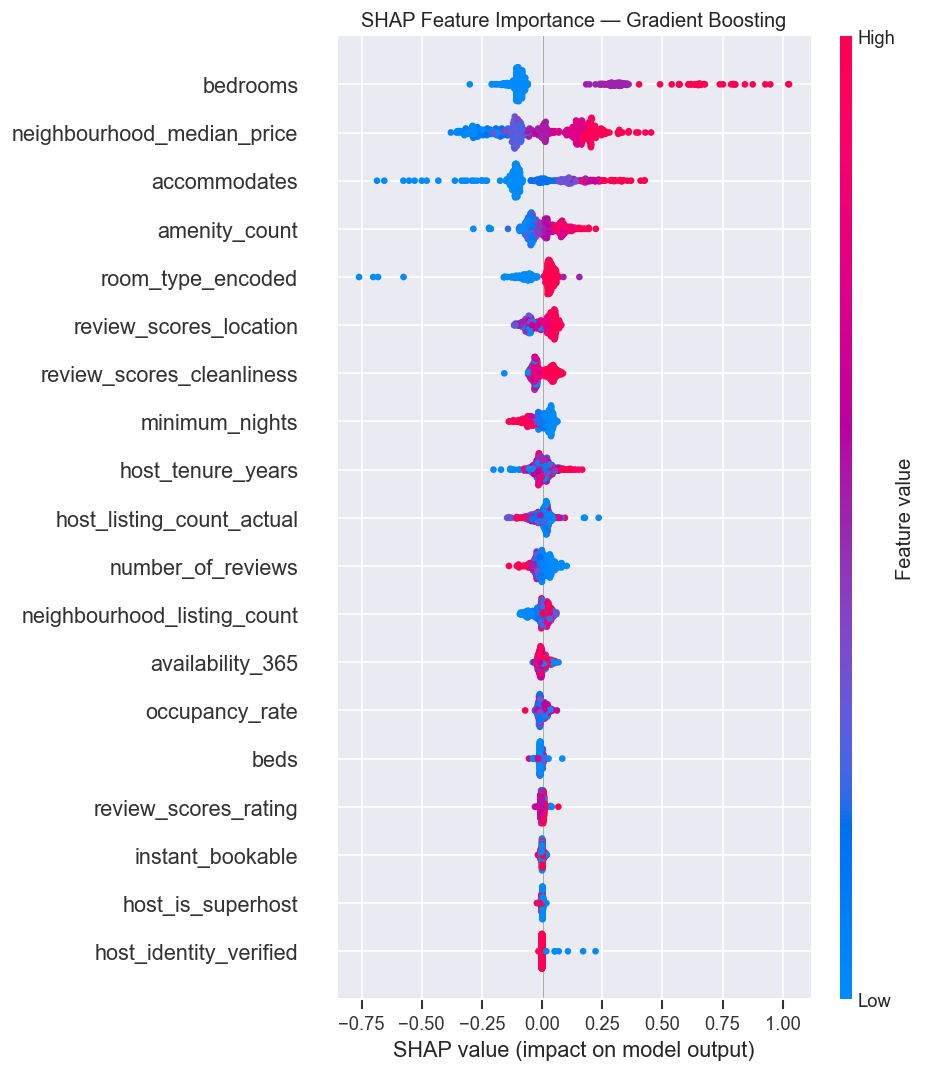


Top 5 features by importance:
bedrooms                      0.431933
neighbourhood_median_price    0.169419
accommodates                  0.121723
host_tenure_years             0.043028
host_listing_count_actual     0.042639
dtype: float64


In [9]:
import shap

best_model = results["GradientBoosting"]["model"]

# Feature importance from model
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=existing_features
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
feat_imp.plot(kind="barh", ax=axes[0], color="#00d4ff")
axes[0].invert_yaxis()
axes[0].set_title("Feature Importance — Gradient Boosting")
axes[0].set_xlabel("Importance Score")

# Model comparison
models = ["Ridge Regression", "Random Forest", "Gradient Boosting"]
maes = [results["Ridge"]["MAE"], results["RandomForest"]["MAE"], 
        results["GradientBoosting"]["MAE"]]
r2s = [results["Ridge"]["R2"], results["RandomForest"]["R2"], 
       results["GradientBoosting"]["R2"]]

x = np.arange(len(models))
axes[1].bar(x - 0.2, maes, 0.4, label="MAE (฿)", color="#ff6b6b")
ax2 = axes[1].twinx()
ax2.bar(x + 0.2, r2s, 0.4, label="R²", color="#4ade80", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylabel("MAE (฿)", color="#ff6b6b")
ax2.set_ylabel("R²", color="#4ade80")
axes[1].set_title("Model Comparison — MAE vs R²")
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.suptitle("Bangkok Airbnb — Price Prediction Model Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/10_ml_model_comparison.png")
plt.show()

# SHAP
print("Computing SHAP values...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test.iloc[:500], 
                  feature_names=existing_features,
                  show=False)
plt.title("SHAP Feature Importance — Gradient Boosting")
plt.tight_layout()
plt.savefig("figures/11_shap_summary.png", bbox_inches="tight")
plt.show()

print("\nTop 5 features by importance:")
print(feat_imp.head(5))

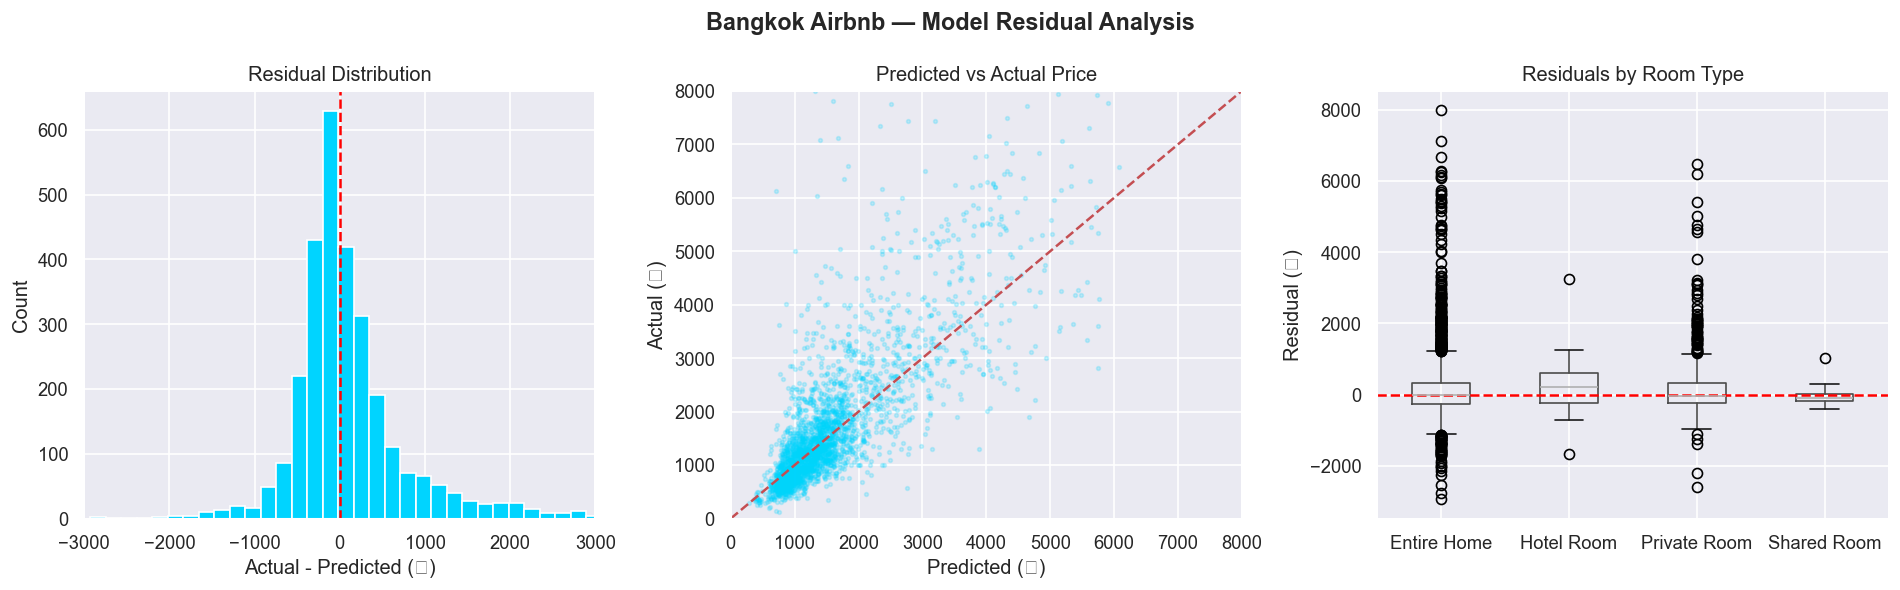

Mean residual: ฿180
Std residual: ฿919
% predictions within ฿500: 72.2%
% predictions within ฿1000: 87.3%


In [10]:
# --- Residual Analysis ---
best_preds = results["GradientBoosting"]["predictions"]
y_actual = np.expm1(y_test)
residuals = y_actual.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals distribution
axes[0].hist(residuals, bins=60, color="#00d4ff", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Actual - Predicted (฿)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(-3000, 3000)

# Predicted vs Actual
axes[1].scatter(best_preds, y_actual.values, alpha=0.2, 
                color="#00d4ff", s=5)
max_val = min(8000, y_actual.max())
axes[1].plot([0, max_val], [0, max_val], "r--", lw=1.5)
axes[1].set_title("Predicted vs Actual Price")
axes[1].set_xlabel("Predicted (฿)")
axes[1].set_ylabel("Actual (฿)")
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)

# Residuals by room type
test_df = X_test.copy()
test_df["residual"] = residuals
test_df["room_type_encoded"] = test_df["room_type_encoded"]
room_map = {3:"Entire Home", 2:"Hotel Room", 1:"Private Room", 0:"Shared Room"}
test_df["room_type_label"] = test_df["room_type_encoded"].map(room_map)
test_df.boxplot(column="residual", by="room_type_label", ax=axes[2])
axes[2].set_title("Residuals by Room Type")
axes[2].set_xlabel("")
axes[2].set_ylabel("Residual (฿)")
axes[2].axhline(0, color="red", linestyle="--")
plt.suptitle("")

plt.suptitle("Bangkok Airbnb — Model Residual Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/12_residual_analysis.png")
plt.show()

print(f"Mean residual: ฿{residuals.mean():,.0f}")
print(f"Std residual: ฿{residuals.std():,.0f}")
print(f"% predictions within ฿500: {(abs(residuals) < 500).mean():.1%}")
print(f"% predictions within ฿1000: {(abs(residuals) < 1000).mean():.1%}")